Mounted at /content/drive
Dataset shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


Problem 2a - Normalization
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 849748793747.9463
Final Validation Loss = 1458033578362.7139

Learning Rate = 0.025
Final Training Loss = 756881074479.9619
Final Validation Loss = 1286272444485.2039

Learning Rate = 0.05
Final Training Loss = 704035112745.0894
Final Validation Loss = 1196908120183.3801

Learning Rate = 0.075
Final Training Loss = 685982783739.0153
Final Validation Loss = 1168303940768.4778

Learning Rate = 0.1
Final Training Loss = 679326731187.338
Final Validation Loss = 1156827430615.011


----------------------------------------------------------------------
BEST RESULT
-----------

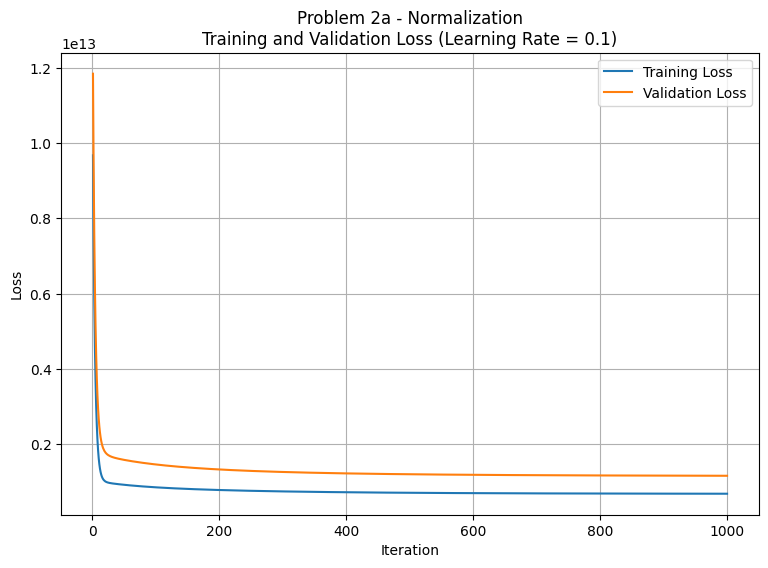



Problem 2a - Standardization
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 675004510848.4789
Final Validation Loss = 1146408168889.5422

Learning Rate = 0.025
Final Training Loss = 675004105663.3005
Final Validation Loss = 1146360776932.8364

Learning Rate = 0.05
Final Training Loss = 675004105663.2902
Final Validation Loss = 1146360772862.6858

Learning Rate = 0.075
Final Training Loss = 675004105663.2902
Final Validation Loss = 1146360772862.6838

Learning Rate = 0.1
Final Training Loss = 675004105663.2902
Final Validation Loss = 1146360772862.6836


----------------------------------------------------------------------
BEST RESULT
----------------------------------------------------------------------
Problem: Problem 2a
Scaling: Standardization
Best Learning Rate: 0.1
Final Training Loss: 675004105663.2902
Final Validation Loss: 1146360772862.6836

Best Parameters:
t

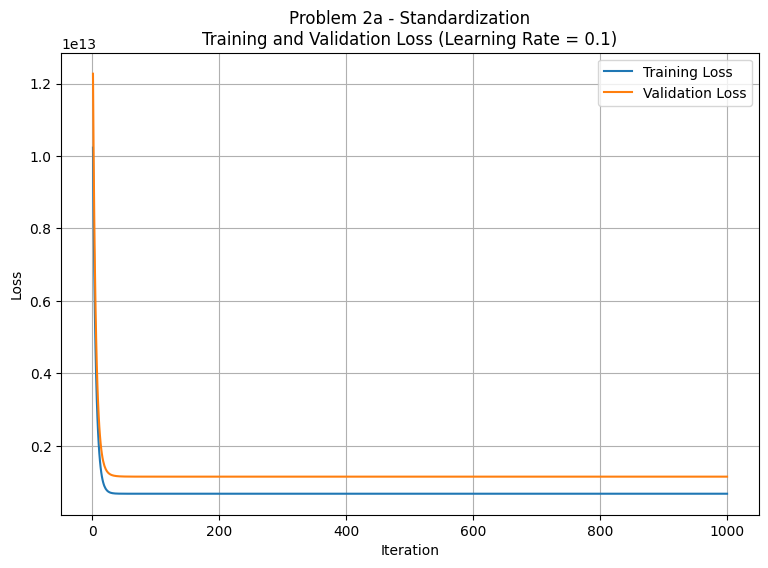



PROBLEM 2a COMPARISON


,Method,Best Learning Rate,Final Training Loss,Final Validation Loss
0,Problem 1a Baseline (No Scaling),None - Diverged,inf,inf
1,Normalization,0.1,6.793267e+11,1.156827e+12
2,Standardization,0.1,6.750041e+11,1.146361e+12



For Problem 2a, standardization achieved the lower final training loss.


Problem 2b - Normalization
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 640942055907.6149
Final Validation Loss = 1077541865435.6562

Learning Rate = 0.025
Final Training Loss = 560083195300.4043
Final Validation Loss = 947263417922.8796

Learning Rate = 0.05
Final Training Loss = 519822018821.4629
Final Validation Loss = 900914192484.2478

Learning Rate = 0.075
Final Training Loss = 505899806958.4956
Final Validation Loss = 892387795383.6545

Learning Rate = 0.1
Final Training Loss = 500403900500.54535
Final Validation Loss = 891968202704.1312


----------------------------------------------------------------------
BEST RESULT
----------------------------------------------------------------------
Problem: Problem 2b
Scaling: Normalization
Best Learning Rate: 0.1
Final Training Loss: 500403900500.

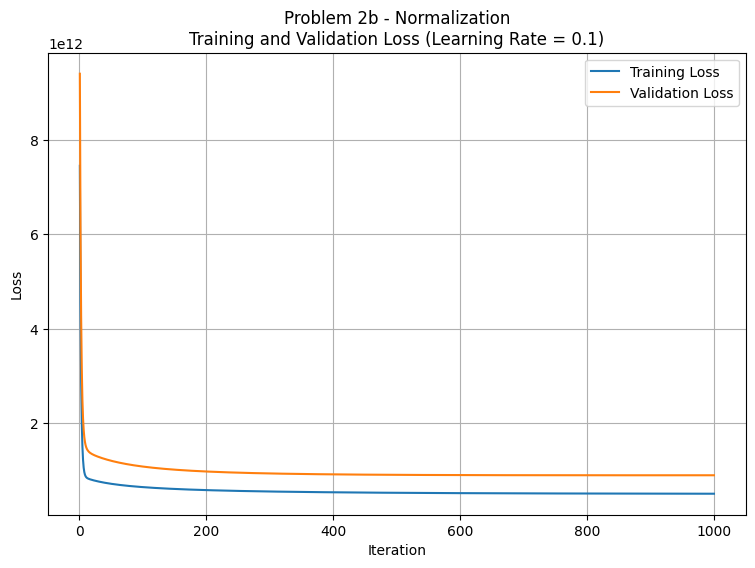



Problem 2b - Standardization
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 496244544318.54205
Final Validation Loss = 900111363844.0186

Learning Rate = 0.025
Final Training Loss = 496240500031.44006
Final Validation Loss = 900396385598.1146

Learning Rate = 0.05
Final Training Loss = 496240500004.89264
Final Validation Loss = 900396859838.0833

Learning Rate = 0.075
Final Training Loss = 496240500004.89264
Final Validation Loss = 900396859859.486

Learning Rate = 0.1
Final Training Loss = 496240500004.89264
Final Validation Loss = 900396859859.4866


----------------------------------------------------------------------
BEST RESULT
----------------------------------------------------------------------
Problem: Problem 2b
Scaling: Standardization
Best Learning Rate: 0.01
Final Training Loss: 496244544318.54205
Final Validation Loss: 900111363844.0186

Best Parameters:
t

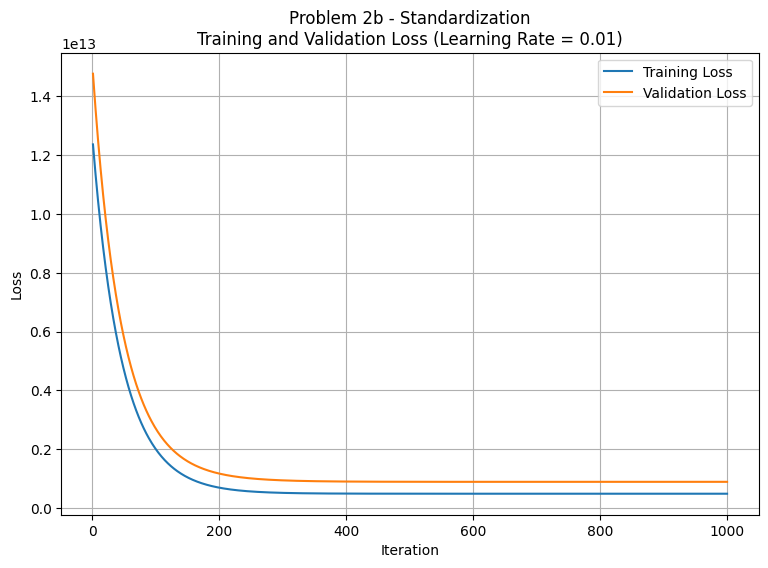



PROBLEM 2b COMPARISON


,Method,Best Learning Rate,Final Training Loss,Final Validation Loss
0,Problem 1b Baseline (No Scaling),None - Diverged,inf,inf
1,Normalization,0.1,5.004039e+11,8.919682e+11
2,Standardization,0.01,4.962445e+11,9.001114e+11



For Problem 2b, standardization achieved the lower final training loss.


In [1]:
# ============================================================
# HOMEWORK 2 - PROBLEM 2
# Linear Regression with Input Normalization and Standardization
# Gradient Descent Implemented From Scratch
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# ============================================================
# LOAD DATASET
# ============================================================

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Housing.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# CONVERT YES/NO VARIABLES TO 1/0
# ============================================================

yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in yes_no_columns:
    df[column] = df[column].map({
        'yes': 1,
        'no': 0
    })


# ============================================================
# LOSS FUNCTION
# ============================================================

def compute_loss(X, y, theta):

    m = len(y)

    predictions = X @ theta
    errors = predictions - y

    loss = (1 / (2 * m)) * np.sum(errors ** 2)

    return loss


# ============================================================
# GRADIENT DESCENT FROM SCRATCH
# ============================================================

def gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    iterations
):

    m = len(y_train)

    # Add intercept column
    X_train_bias = np.c_[
        np.ones(m),
        X_train
    ]

    X_val_bias = np.c_[
        np.ones(len(y_val)),
        X_val
    ]

    # Initialize theta values to zero
    theta = np.zeros(X_train_bias.shape[1])

    train_losses = []
    val_losses = []

    for i in range(iterations):

        # Predictions
        predictions = X_train_bias @ theta

        # Errors
        errors = predictions - y_train

        # Gradient
        gradient = (
            1 / m
        ) * (
            X_train_bias.T @ errors
        )

        # Update theta
        theta = theta - learning_rate * gradient

        # Training loss
        train_loss = compute_loss(
            X_train_bias,
            y_train,
            theta
        )

        # Validation loss
        val_loss = compute_loss(
            X_val_bias,
            y_val,
            theta
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses


# ============================================================
# RUN ONE SCALING EXPERIMENT
# ============================================================

def run_scaled_experiment(
    X,
    y,
    feature_names,
    problem_name,
    scaling_method,
    learning_rates,
    iterations
):

    # --------------------------------------------------------
    # 80/20 TRAINING AND VALIDATION SPLIT
    # --------------------------------------------------------

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    X_train = np.array(X_train, dtype=float)
    X_val = np.array(X_val, dtype=float)

    y_train = np.array(y_train, dtype=float)
    y_val = np.array(y_val, dtype=float)


    # --------------------------------------------------------
    # INPUT SCALING
    # Output y is NOT scaled
    # --------------------------------------------------------

    if scaling_method == 'Normalization':

        scaler = MinMaxScaler()

    elif scaling_method == 'Standardization':

        scaler = StandardScaler()

    else:

        raise ValueError(
            "Scaling method must be Normalization or Standardization"
        )


    # Fit scaler only on training inputs
    X_train_scaled = scaler.fit_transform(X_train)

    # Use same scaler on validation inputs
    X_val_scaled = scaler.transform(X_val)


    print("\n")
    print("=" * 70)
    print(problem_name, "-", scaling_method)
    print("=" * 70)

    print("Training samples:", len(X_train_scaled))
    print("Validation samples:", len(X_val_scaled))
    print("Iterations:", iterations)
    print("Learning rates tested:", learning_rates)


    results = {}


    # --------------------------------------------------------
    # TEST DIFFERENT LEARNING RATES
    # --------------------------------------------------------

    for alpha in learning_rates:

        theta, train_losses, val_losses = gradient_descent(
            X_train_scaled,
            y_train,
            X_val_scaled,
            y_val,
            learning_rate=alpha,
            iterations=iterations
        )

        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]

        results[alpha] = {
            'theta': theta,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'final_train_loss': final_train_loss,
            'final_val_loss': final_val_loss
        }

        print("\nLearning Rate =", alpha)

        print(
            "Final Training Loss =",
            final_train_loss
        )

        print(
            "Final Validation Loss =",
            final_val_loss
        )


    # --------------------------------------------------------
    # SELECT BEST LEARNING RATE
    # Lowest final validation loss
    # --------------------------------------------------------

    best_alpha = min(
        results,
        key=lambda alpha:
        results[alpha]['final_val_loss']
    )

    best_result = results[best_alpha]

    best_theta = best_result['theta']

    print("\n")
    print("-" * 70)
    print("BEST RESULT")
    print("-" * 70)

    print("Problem:", problem_name)
    print("Scaling:", scaling_method)

    print(
        "Best Learning Rate:",
        best_alpha
    )

    print(
        "Final Training Loss:",
        best_result['final_train_loss']
    )

    print(
        "Final Validation Loss:",
        best_result['final_val_loss']
    )


    # --------------------------------------------------------
    # PRINT BEST PARAMETERS
    # --------------------------------------------------------

    print("\nBest Parameters:")

    print(
        "theta_0 (intercept) =",
        best_theta[0]
    )

    for i, feature in enumerate(feature_names):

        print(
            f"theta_{i+1} ({feature}) =",
            best_theta[i+1]
        )


    # --------------------------------------------------------
    # PLOT TRAINING AND VALIDATION LOSS
    # --------------------------------------------------------

    plt.figure(figsize=(9, 6))

    plt.plot(
        range(1, iterations + 1),
        best_result['train_losses'],
        label='Training Loss'
    )

    plt.plot(
        range(1, iterations + 1),
        best_result['val_losses'],
        label='Validation Loss'
    )

    plt.xlabel('Iteration')
    plt.ylabel('Loss')

    plt.title(
        f'{problem_name} - {scaling_method}\n'
        f'Training and Validation Loss '
        f'(Learning Rate = {best_alpha})'
    )

    plt.legend()
    plt.grid(True)

    plt.show()


    return {
        'problem': problem_name,
        'scaling': scaling_method,
        'best_alpha': best_alpha,
        'theta': best_theta,
        'train_loss': best_result['final_train_loss'],
        'val_loss': best_result['final_val_loss']
    }


# ============================================================
# SETTINGS
# ============================================================

learning_rates = [
    0.01,
    0.025,
    0.05,
    0.075,
    0.1
]

iterations = 1000

y = df['price'].values


# ============================================================
# PROBLEM 2a
# Repeat Problem 1a with Normalization and Standardization
# ============================================================

features_2a = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

X_2a = df[features_2a].values


# ------------------------------------------------------------
# 2a - NORMALIZATION
# ------------------------------------------------------------

result_2a_normalization = run_scaled_experiment(
    X=X_2a,
    y=y,
    feature_names=features_2a,
    problem_name='Problem 2a',
    scaling_method='Normalization',
    learning_rates=learning_rates,
    iterations=iterations
)


# ------------------------------------------------------------
# 2a - STANDARDIZATION
# ------------------------------------------------------------

result_2a_standardization = run_scaled_experiment(
    X=X_2a,
    y=y,
    feature_names=features_2a,
    problem_name='Problem 2a',
    scaling_method='Standardization',
    learning_rates=learning_rates,
    iterations=iterations
)


# ============================================================
# PROBLEM 2a COMPARISON
# ============================================================

print("\n")
print("=" * 70)
print("PROBLEM 2a COMPARISON")
print("=" * 70)

comparison_2a = pd.DataFrame({

    'Method': [
        'Problem 1a Baseline (No Scaling)',
        'Normalization',
        'Standardization'
    ],

    'Best Learning Rate': [
        'None - Diverged',
        result_2a_normalization['best_alpha'],
        result_2a_standardization['best_alpha']
    ],

    'Final Training Loss': [
        np.inf,
        result_2a_normalization['train_loss'],
        result_2a_standardization['train_loss']
    ],

    'Final Validation Loss': [
        np.inf,
        result_2a_normalization['val_loss'],
        result_2a_standardization['val_loss']
    ]

})

display(comparison_2a)


if (
    result_2a_normalization['train_loss']
    <
    result_2a_standardization['train_loss']
):

    print(
        "\nFor Problem 2a, normalization achieved "
        "the lower final training loss."
    )

else:

    print(
        "\nFor Problem 2a, standardization achieved "
        "the lower final training loss."
    )


# ============================================================
# PROBLEM 2b
# Repeat Problem 1b with Normalization and Standardization
# ============================================================

features_2b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_2b = df[features_2b].values


# ------------------------------------------------------------
# 2b - NORMALIZATION
# ------------------------------------------------------------

result_2b_normalization = run_scaled_experiment(
    X=X_2b,
    y=y,
    feature_names=features_2b,
    problem_name='Problem 2b',
    scaling_method='Normalization',
    learning_rates=learning_rates,
    iterations=iterations
)


# ------------------------------------------------------------
# 2b - STANDARDIZATION
# ------------------------------------------------------------

result_2b_standardization = run_scaled_experiment(
    X=X_2b,
    y=y,
    feature_names=features_2b,
    problem_name='Problem 2b',
    scaling_method='Standardization',
    learning_rates=learning_rates,
    iterations=iterations
)


# ============================================================
# PROBLEM 2b COMPARISON
# ============================================================

print("\n")
print("=" * 70)
print("PROBLEM 2b COMPARISON")
print("=" * 70)

comparison_2b = pd.DataFrame({

    'Method': [
        'Problem 1b Baseline (No Scaling)',
        'Normalization',
        'Standardization'
    ],

    'Best Learning Rate': [
        'None - Diverged',
        result_2b_normalization['best_alpha'],
        result_2b_standardization['best_alpha']
    ],

    'Final Training Loss': [
        np.inf,
        result_2b_normalization['train_loss'],
        result_2b_standardization['train_loss']
    ],

    'Final Validation Loss': [
        np.inf,
        result_2b_normalization['val_loss'],
        result_2b_standardization['val_loss']
    ]

})

display(comparison_2b)


if (
    result_2b_normalization['train_loss']
    <
    result_2b_standardization['train_loss']
):

    print(
        "\nFor Problem 2b, normalization achieved "
        "the lower final training loss."
    )

else:

    print(
        "\nFor Problem 2b, standardization achieved "
        "the lower final training loss."
    )